In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

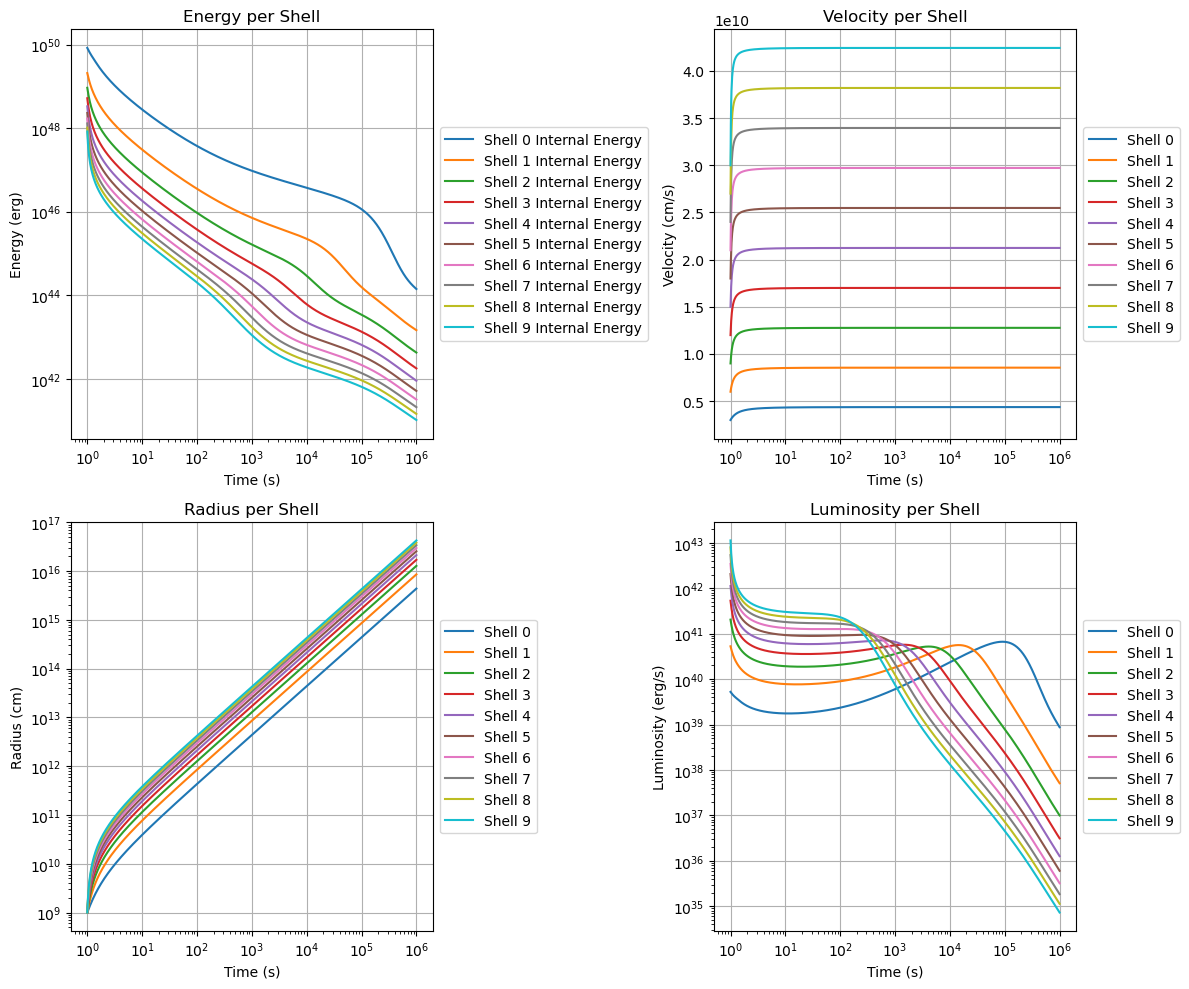

In [2]:
# Constants
M_sun = 2e33             # Solar mass in g
M_tot = 0.01 * M_sun     # Total mass of the ejecta in g
c = 3e10                 # Speed of light in cm/s
v_min = 0.1 * c          # Minimum velocity of massive shell in cm/s
beta = 3                 # factor for homologous expansion - ensures shells never overlap 
numshells = 10           # Number of shells

#Time array
t = np.logspace(0, 6, 1000)              
# Velocity array for each shell
v_shells = np.linspace(0.1, 1, numshells)* c

# Mass distribution
M_shells = beta * M_tot * (v_min**(beta)) * (v_shells**(-beta-1))    # Mass fraction based on velocity
M_shells = M_shells * M_tot / np.sum(M_shells)                       # Normalised so the shells sum to M_0
E_int_shells =  0.5 * M_shells * (v_shells**2)                     # Internal energy per shell, assming kinetic energy is similar to internal energy

#Dataframe of properties
shell_data = pd.DataFrame({'Velocity (cm/s)': v_shells, 'Mass (g)': M_shells, 'Internal Energy (erg)': E_int_shells})

# Constants associated with heating and radiative loss terms
av = 0.56
bv = 0.71
cv = 0.74
xr = 0.6
kv = [20, 5, 1]                  # Opacity ranges for kilonova colors

# Heating efficiency as a function of time
def eps_th_v(t):
    t_day = t / 86400  # Convert seconds to days
    exp_term = np.exp(-av * t_day)
    log_term = np.log(1 + 2 * bv * t_day**cv)
    result = 0.36 * (exp_term + (log_term / (2 * bv * t_day**cv)))
    return result

# R-process energy deposition rate
def e_dot_r(t):
    t0 = 1.3  
    sigma = 0.11  
    arctan_term = np.arctan((t - t0) / sigma)
    result = 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * arctan_term)**1.3
    return result

# Heating due to radioactive decay
def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

# Diffusion time
def t_diff(M_shells, t):
    return ((M_shells**(4./3.)) * kv[2]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

# Radiative losses
def L_v(R, Eint, t_diff):
    t_lc = (R / c)                            # Light-crossing time
    return Eint / (t_diff + t_lc)

# ODEs governing energy and dynamics
def energy(y, t, M):
    Eint, R, v = y
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]

# Solving for each shell
E_all = []
R_all = []
v_all = []

for i, row in shell_data.iterrows():
    M = row['Mass (g)']
    Eint0 = row['Internal Energy (erg)']
    v0 = row['Velocity (cm/s)']
    R0 = 1e9  # Initial radius
    y0 = [Eint0, R0, v0]

    Edep = odeint(energy, y0, t, args=(M,))
    E_all.append(Edep[:, 0])  
    R_all.append(Edep[:, 1])  
    v_all.append(Edep[:, 2])  

# Plotting results
plt.figure(figsize=(12, 10))

# Energy per shell
plt.subplot(2, 2, 1)
for i, E in enumerate(E_all):
    plt.loglog(t, E, label=f'Shell {i} Internal Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (erg)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Energy per Shell')
plt.grid(True)

# Velocity per shell
plt.subplot(2, 2, 2)
for i, v in enumerate(v_all):
    plt.plot(t, v, label=f'Shell {i}')
plt.xscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (cm/s)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Velocity per Shell')
plt.grid(True)

# Radius per shell
plt.subplot(2, 2, 3)
for i, R in enumerate(R_all):
    plt.loglog(t, R, label=f'Shell {i}')
plt.xlabel('Time (s)')
plt.ylabel('Radius (cm)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Radius per Shell')
plt.grid(True)

# Luminosity per shell
plt.subplot(2, 2, 4)
for i, (R, Eint) in enumerate(zip(R_all, E_all)):
    lv_values = L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t))
    plt.loglog(t, lv_values, label=f'Shell {i}')
plt.xlabel('Time (s)')
plt.ylabel('Luminosity (erg/s)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Luminosity per Shell')
plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 5.67e-5    # Stefan's constant in erg / cm^2 / s / K^4
h = 6.626e-27      # Planck's constant in erg * s
nu = 5e15          # Frequency (Hz), can be altered to see fluxes of different frequencies
kB = 1.38e-16      # Boltzmann's constant in erg / K
D = 1e26           # Luminosity distance in cm, as used by Metzger in his paper (100 Mpc)

T_eff = []
for i in range(len(R_peak)):
    T_eff_shell = (L_tot / (4*np.pi *sigma*(R_peak[i]**2)))**(1/4)
    T_eff.append(T_eff_shell)
    
print(T_eff)

Flux = []
for i in range(len(T_eff)):
    Flux_shell = ((2 * np.pi * h * (nu**3)) / (c**2)) * (1 / (np.exp((h * nu) / (kB * T_eff[i])) - 1)) * (R_peak[i]**2 / D**2)
    Flux.append(Flux_shell)  # Append the flux for each shell


# You likely want to sum or average the fluxes from all shells. Here's an example of summing:
Flux_total = np.sum(Flux, axis=0)  # Sum over all shells if Flux is a list of arrays

# Plotting the flux
plt.figure(figsize=(8, 6))
plt.loglog(t, Flux_total, label='Total Flux')  # Plot the total flux (sum of all shells)
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm^2/s)')
plt.title('Flux Evolution over Time')
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'R_peak' is not defined